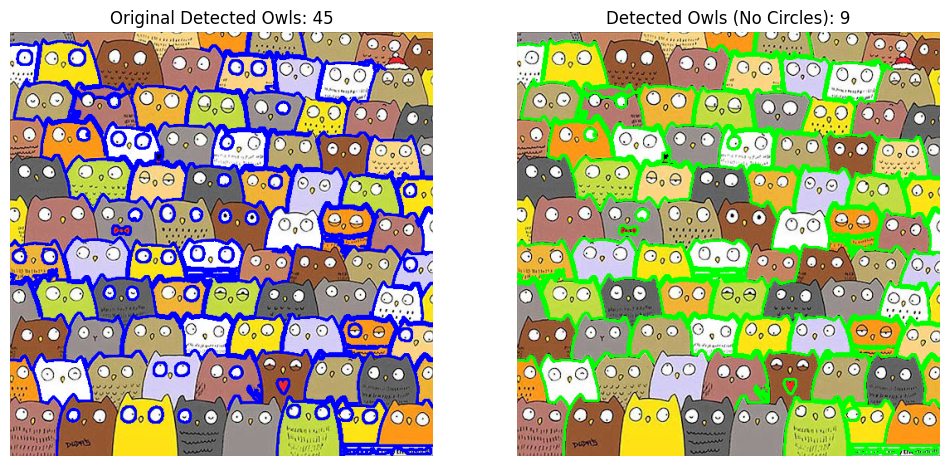

9

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh từ đường dẫn
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"  # Thay thế bằng đường dẫn ảnh thực tế
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Áp dụng bộ lọc để phát hiện cạnh
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Tìm contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Lọc bỏ các contours nhỏ
min_contour_area = 150  # Giữ lại các cú nhỏ
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

# Tạo bản sao ảnh để vẽ kết quả
result_image = image.copy()
cv2.drawContours(result_image, filtered_contours, -1, (255, 0, 0), 2)

# Hàm tính độ tròn của một contour
def circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return 0
    return (4 * np.pi * area) / (perimeter ** 2)

# Ngưỡng để xác định hình tròn (mắt cú)
circularity_threshold = 0.75

# Lọc bỏ các hình tròn (mắt cú)
filtered_contours_no_circles = [
    cnt for cnt in filtered_contours 
    if circularity(cnt) < circularity_threshold
]

# Vẽ contours sau khi loại bỏ hình tròn
result_image_no_circles = image.copy()
cv2.drawContours(result_image_no_circles, filtered_contours_no_circles, -1, (0, 255, 0), 2)

# Số lượng cú sau khi loại bỏ hình tròn
num_owls_no_circles = len(filtered_contours_no_circles)

# Hiển thị kết quả
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Original Detected Owls: {len(filtered_contours)}")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(result_image_no_circles, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Detected Owls (No Circles): {num_owls_no_circles}")
ax[1].axis("off")

plt.show()

# Trả về số lượng cú sau khi loại bỏ hình tròn
num_owls_no_circles


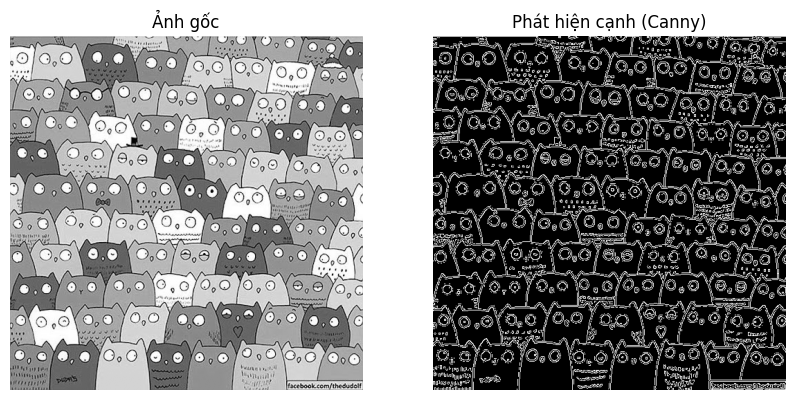

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Phát hiện cạnh bằng thuật toán Canny
edges = cv2.Canny(image, 100, 200)

# Hiển thị ảnh gốc và ảnh cạnh
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Phát hiện cạnh (Canny)")
plt.axis("off")

plt.show()


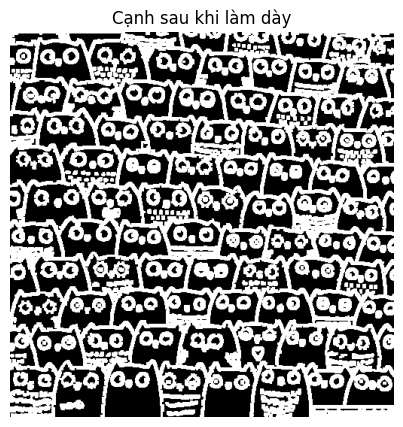

In [3]:
# Làm dày đường viền bằng phép toán giãn nở (Dilation)
kernel = np.ones((3,3), np.uint8)  # Kernel 3x3 để làm dày cạnh
edges_dilated = cv2.dilate(edges, kernel, iterations=1)

# Hiển thị ảnh cạnh đã làm dày
plt.figure(figsize=(5, 5))
plt.imshow(edges_dilated, cmap="gray")
plt.title("Cạnh sau khi làm dày")
plt.axis("off")
plt.show()


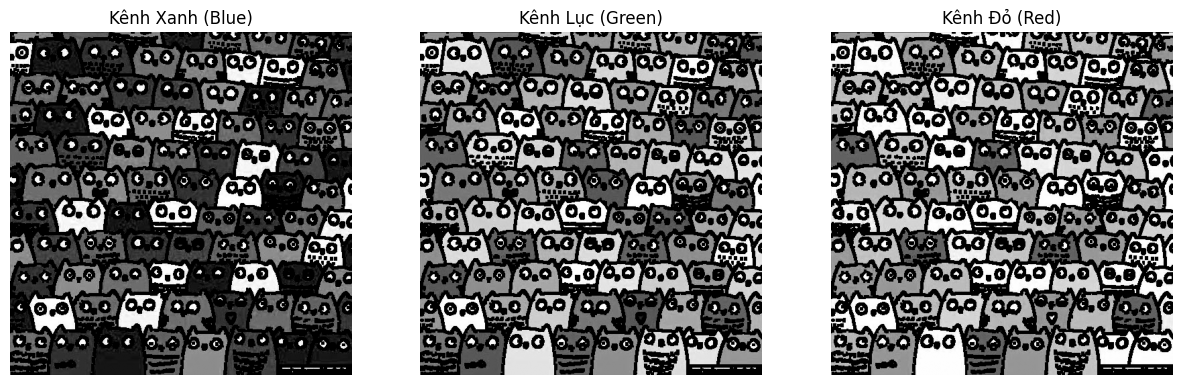

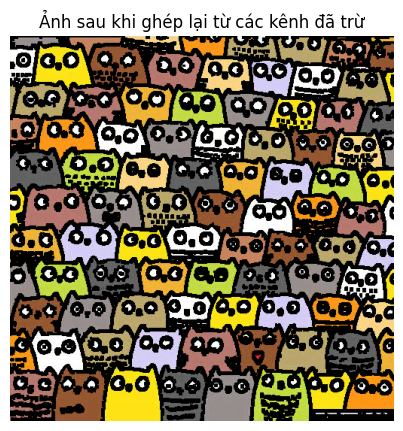

In [4]:
# Tách từng kênh màu từ ảnh gốc
image_rgb = cv2.imread("/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg", cv2.IMREAD_COLOR)
blue_channel, green_channel, red_channel = cv2.split(image_rgb)

# Trừ từng kênh màu với ảnh đen trắng
blue_subtract = cv2.subtract(blue_channel, edges_dilated)
green_subtract = cv2.subtract(green_channel, edges_dilated)
red_subtract = cv2.subtract(red_channel, edges_dilated)

image_merged = cv2.merge((blue_subtract, green_subtract, red_subtract))
# Hiển thị kết quả từng kênh sau khi trừ
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(blue_subtract, cmap="gray")
axs[0].set_title("Kênh Xanh (Blue)")

axs[1].imshow(green_subtract, cmap="gray")
axs[1].set_title("Kênh Lục (Green)")

axs[2].imshow(red_subtract, cmap="gray")
axs[2].set_title("Kênh Đỏ (Red)")

for ax in axs:
    ax.axis("off")

plt.show()
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image_merged, cv2.COLOR_BGR2RGB))
plt.title("Ảnh sau khi ghép lại từ các kênh đã trừ")
plt.axis("off")
plt.show()


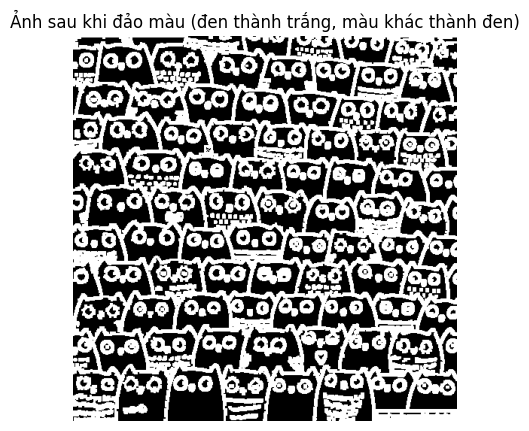

In [21]:
# Chuyển đổi ảnh: màu đen thành trắng, màu khác thành đen
image_binary = cv2.threshold(cv2.cvtColor(image_merged, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY_INV)[1]

# Hiển thị kết quả
plt.figure(figsize=(5, 5))
plt.imshow(image_binary, cmap="gray")
plt.title("Ảnh sau khi đảo màu (đen thành trắng, màu khác thành đen)")
plt.axis("off")
plt.show()


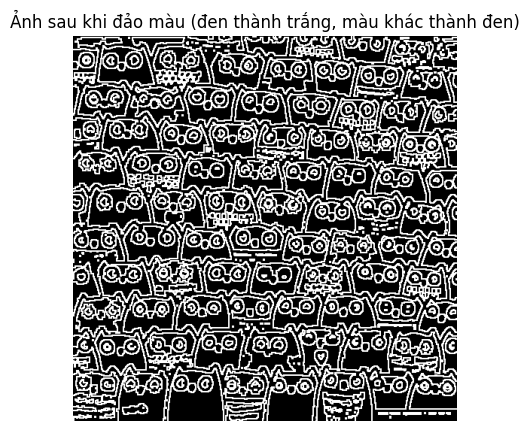

In [35]:
kernel = np.ones((3,3), np.uint8)
gradient = cv2.morphologyEx(image_binary, cv2.MORPH_GRADIENT, kernel)
plt.figure(figsize=(5, 5))
plt.imshow(gradient, cmap="gray")
plt.title("Ảnh sau khi đảo màu (đen thành trắng, màu khác thành đen)")
plt.axis("off")
plt.show()


In [ ]:
# Tìm các thành phần liên thông (vùng màu đen) trong ảnh nhị phân
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(image_binary, connectivity=8)


area_threshold = 120
large_black_regions = sum(1 for stat in stats if stat[cv2.CC_STAT_AREA] > area_threshold)

# Hiển thị số lượng vùng màu đen có diện tích lớn hơn 10
large_black_regions


94

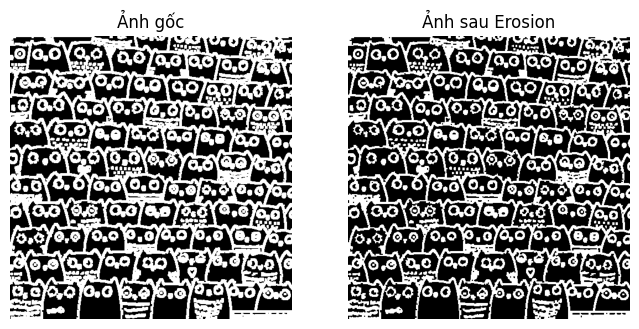

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tạo kernel (cấu trúc phần tử)
kernel = np.ones((2,2), np.uint8)

# Áp dụng phép co (erosion)
eroded_image = cv2.erode(image_binary, kernel, iterations=1)

# Hiển thị kết quả
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_binary, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[0].axis('off')

axes[1].imshow(eroded_image, cmap='gray')
axes[1].set_title('Ảnh sau Erosion')
axes[1].axis('off')

plt.show()

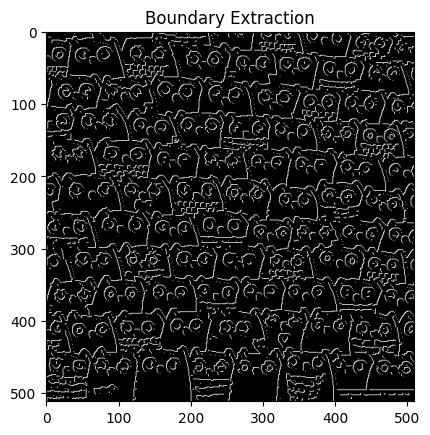

In [9]:
boundary = image_binary - eroded_image
plt.imshow(boundary, cmap='gray')
plt.title('Boundary Extraction')
plt.show()

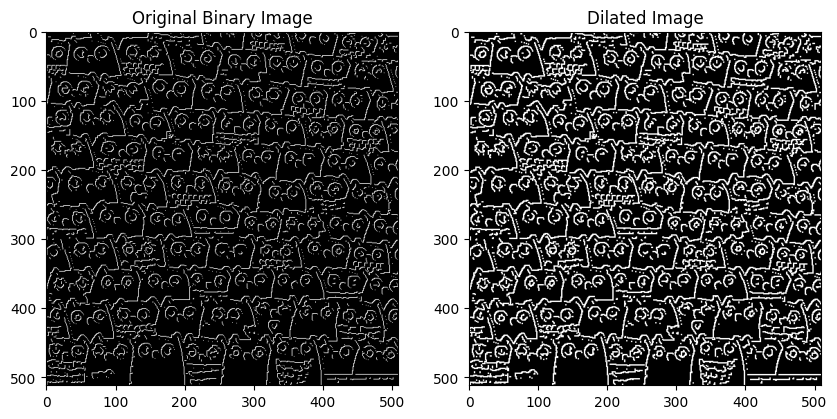

In [10]:
kernel = np.ones((2,2), np.uint8)  # 5x5 square kernel

# Apply Dilation
dilated = cv2.dilate(boundary, kernel, iterations=1)

# Display results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(boundary, cmap='gray'), plt.title('Original Binary Image')
plt.subplot(1,2,2), plt.imshow(dilated, cmap='gray'), plt.title('Dilated Image')
plt.show()

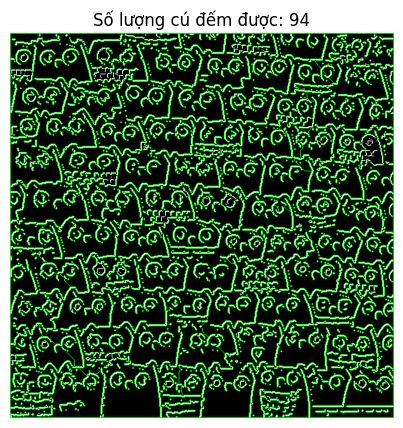

94

In [11]:
# Tiền xử lý lại ảnh để tách các con cú bị dính nhau

# Áp dụng ngưỡng hóa để có ảnh nhị phân rõ ràng hơn
_, binary = cv2.threshold(boundary, 50, 255, cv2.THRESH_BINARY_INV)

# Sử dụng khoảng cách Euclidean (Distance Transform) để tách các vùng dính nhau
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)

# Chuyển đổi kiểu dữ liệu
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(binary, sure_fg)

# Áp dụng Watershed để tách đối tượng
markers = cv2.connectedComponents(sure_fg)[1]
markers = markers + 1  # Để đảm bảo các vùng nền có giá trị khác 0
markers[unknown == 255] = 0  # Đánh dấu vùng không xác định

# Chuyển sang ảnh màu để áp dụng Watershed
image_color = cv2.cvtColor(boundary, cv2.COLOR_GRAY2BGR)
cv2.watershed(image_color, markers)
image_color[markers == -1] = [0, 255, 0]  # Đánh dấu viền vùng bằng màu xanh lá

# Đếm số lượng vùng (số cú)
num_owls = len(np.unique(markers)) - 2  # Trừ vùng nền và vùng chưa xác định

# Hiển thị kết quả
plt.figure(figsize=(10,5))
plt.imshow(image_color)
plt.title(f"Số lượng cú đếm được: {large_black_regions}")
plt.axis("off")
plt.show()

# Trả về số lượng cú đếm được
large_black_regions

In [12]:
import sys
import cv2 as cv
import numpy as np
def main(argv):
    
    default_file = '/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg'
    filename = argv[0] if len(argv) > 0 else default_file
    # Loads an image
    src = cv.imread(cv.samples.findFile(filename), cv.IMREAD_COLOR)
    # Check if image is loaded fine
    if src is None:
        print ('Error opening image!')
        print ('Usage: hough_circle.py [image_name -- default ' + default_file + '] \n')
        return -1
    
    
    gray = cv.cvtColor(src, cv.COLOR_BGR2GRAY)
    
    
    gray = cv.medianBlur(gray, 5)
    
    
    rows = gray.shape[0]
    circles = cv.HoughCircles(gray, cv.HOUGH_GRADIENT, 1, rows / 8,
                               param1=100, param2=30,
                               minRadius=1, maxRadius=30)
    
    
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            center = (i[0], i[1])
            # circle center
            cv.circle(src, center, 1, (0, 100, 100), 3)
            # circle outline
            radius = i[2]
            cv.circle(src, center, radius, (255, 0, 255), 3)
    
    
    cv.imshow("detected circles", src)
    cv.waitKey(0)
    
    return 0
if __name__ == "__main__":
    main(sys.argv[1:])

[ WARN:0@1.213] global samples.cpp:61 findFile cv::samples::findFile('--f=/Users/kaiser_1/Library/Jupyter/runtime/kernel-v39a8dd441bfc93f9a5e22075103b3c31fb9e86efb.json') => ''


error: OpenCV(4.11.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/core/src/utils/samples.cpp:64: error: (-2:Unspecified error) OpenCV samples: Can't find required data file: --f=/Users/kaiser_1/Library/Jupyter/runtime/kernel-v39a8dd441bfc93f9a5e22075103b3c31fb9e86efb.json in function 'findFile'


In [ ]:
import cv2
import numpy as np

# Đọc ảnh
image = cv2.imread("/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Làm mờ ảnh để giảm nhiễu
gray_blur = cv2.GaussianBlur(gray, (9, 9), 2)

# Phát hiện hình tròn bằng Hough Circle Transform
circles = cv2.HoughCircles(gray_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                           param1=50, param2=30, minRadius=10, maxRadius=100)

# Vẽ hình tròn nếu phát hiện được
if circles is not None:
    circles = np.uint16(np.around(circles))  # Làm tròn tọa độ
    for circle in circles[0, :]:
        x, y, r = circle
        cv2.circle(image, (x, y), r, (0, 255, 0), 2)  # Vẽ đường tròn
        cv2.circle(image, (x, y), 2, (0, 0, 255), 3)  # Vẽ tâm hình tròn

# Hiển thị ảnh
cv2.imshow("Detected Circles", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


2025-04-01 16:37:05.247 Python[49914:1387826] +[IMKClient subclass]: chose IMKClient_Modern
2025-04-01 16:37:05.247 Python[49914:1387826] +[IMKInputSession subclass]: chose IMKInputSession_Modern
